## Objetivo

Esta é a análise de abertura do portfólio: uma Análise Exploratória de Dados (EDA) clássica usando o dataset do Titanic, disponível publicamente. O foco é praticar limpeza de dados, visualização e storytelling — a base para qualquer projeto de ML.

Perguntas que queremos responder:

- Qual foi a taxa geral de sobrevivência?
- Sexo e classe do passageiro influenciaram a chance de sobreviver?
- Como a idade se relaciona com a sobrevivência?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Visão geral dos dados

In [2]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

`Age` e `Cabin` têm valores ausentes relevantes. Para esta EDA inicial, vamos manter `Age` (imputando a mediana apenas para os gráficos que precisam dela) e ignorar `Cabin`, que tem poucos dados preenchidos.

## Taxa geral de sobrevivência

Taxa de sobrevivência: 38.4%


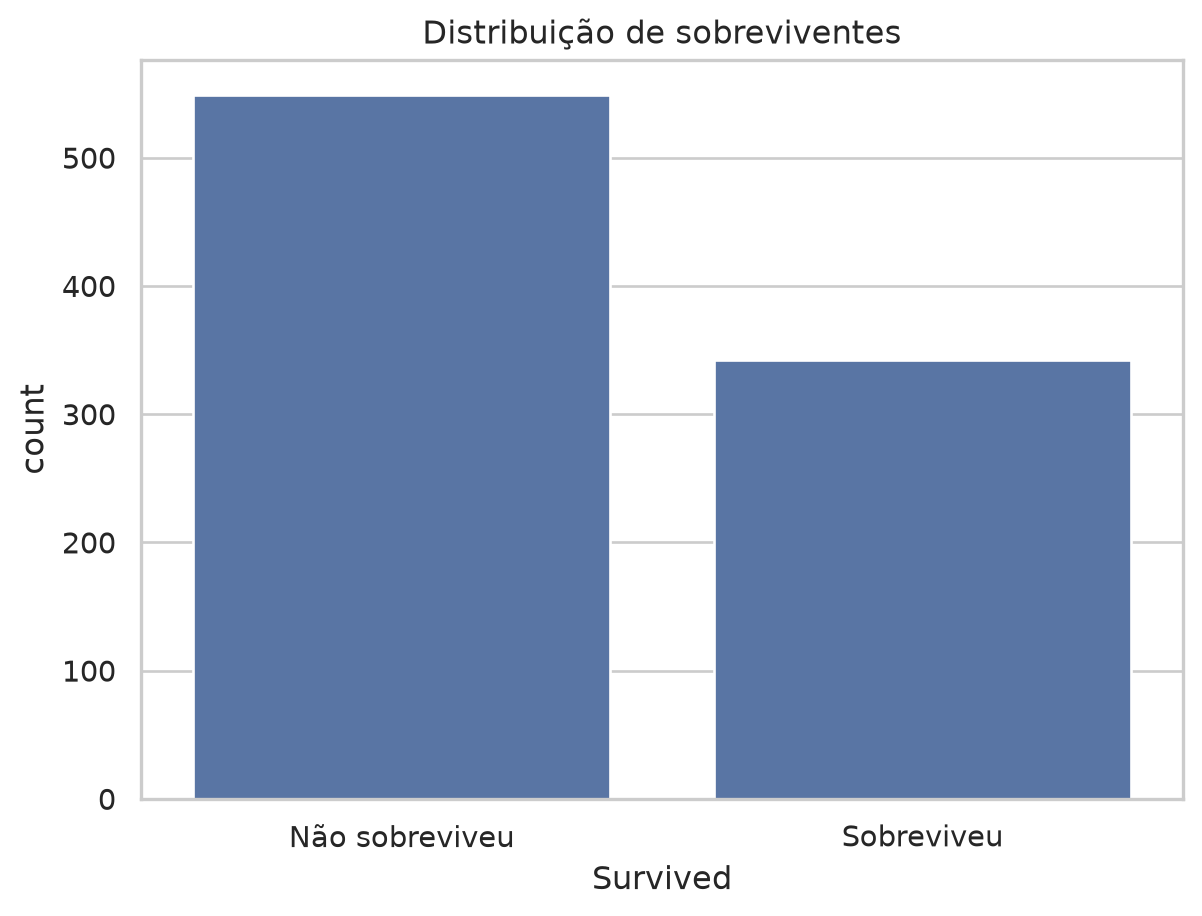

In [3]:
taxa_sobrevivencia = df["Survived"].mean()
print(f"Taxa de sobrevivência: {taxa_sobrevivencia:.1%}")

sns.countplot(data=df, x="Survived")
plt.xticks([0, 1], ["Não sobreviveu", "Sobreviveu"])
plt.title("Distribuição de sobreviventes")
plt.show()

## Sobrevivência por sexo e classe

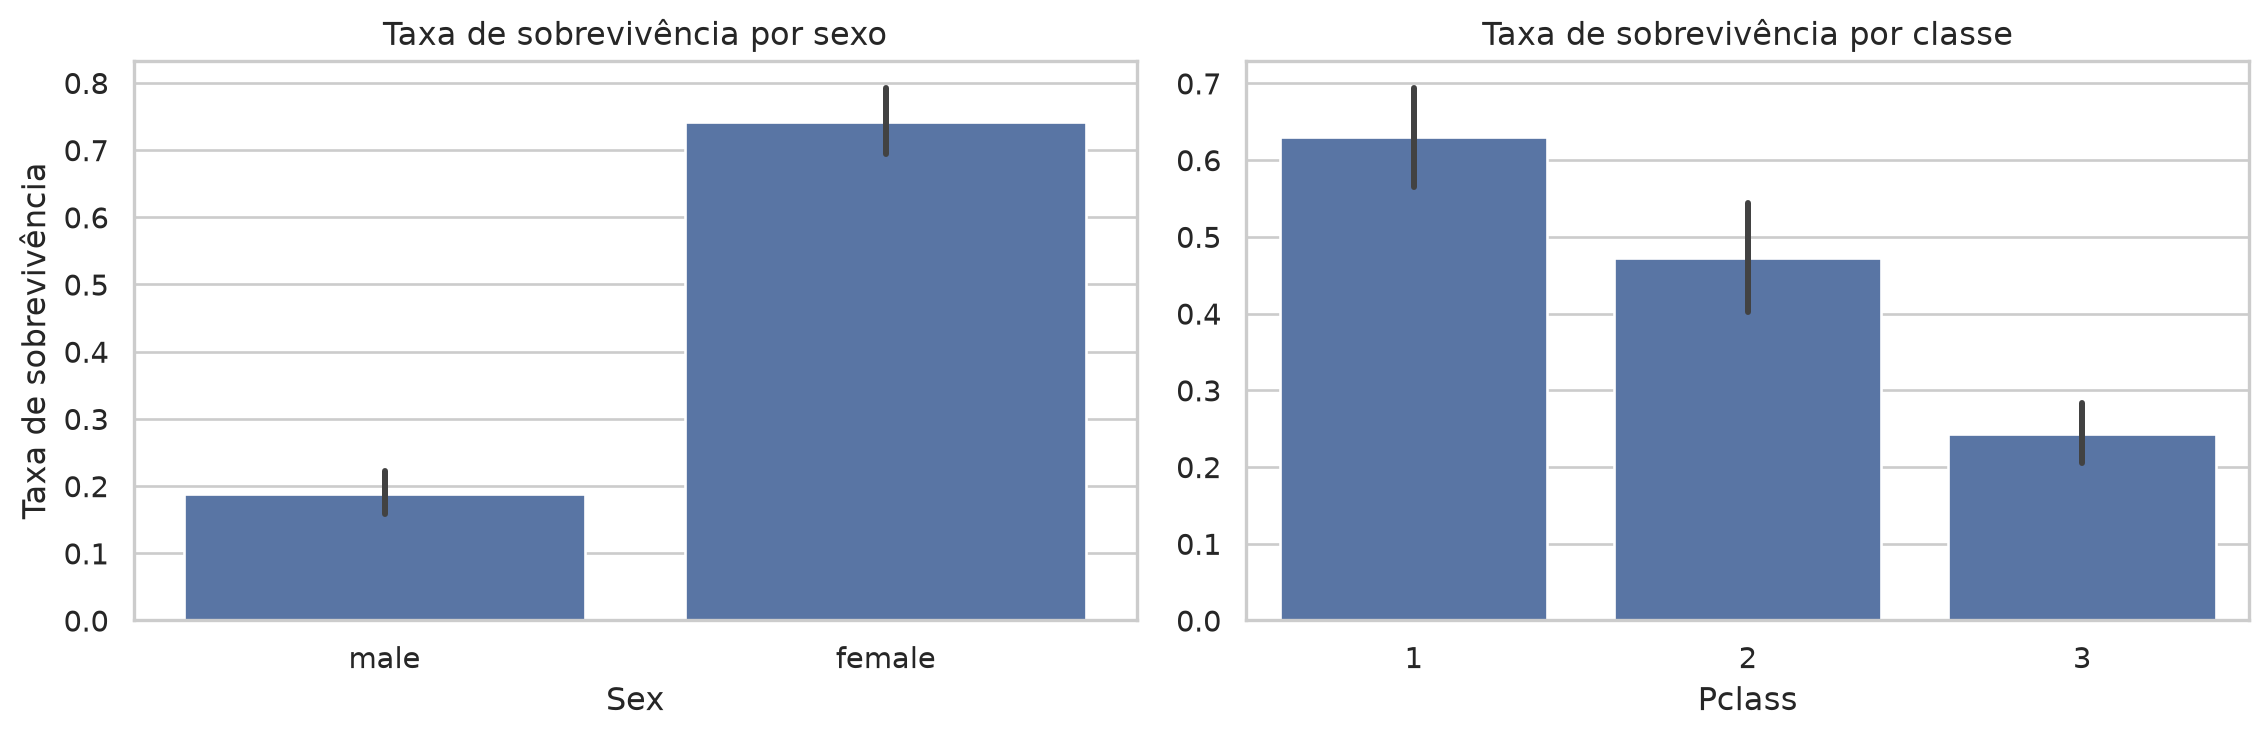

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0])
axes[0].set_title("Taxa de sobrevivência por sexo")
axes[0].set_ylabel("Taxa de sobrevivência")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1])
axes[1].set_title("Taxa de sobrevivência por classe")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Mulheres e passageiros de 1ª classe tiveram taxas de sobrevivência bem mais altas — consistente com a política de "mulheres e crianças primeiro" e o acesso privilegiado aos botes salva-vidas.

## Sobrevivência por idade

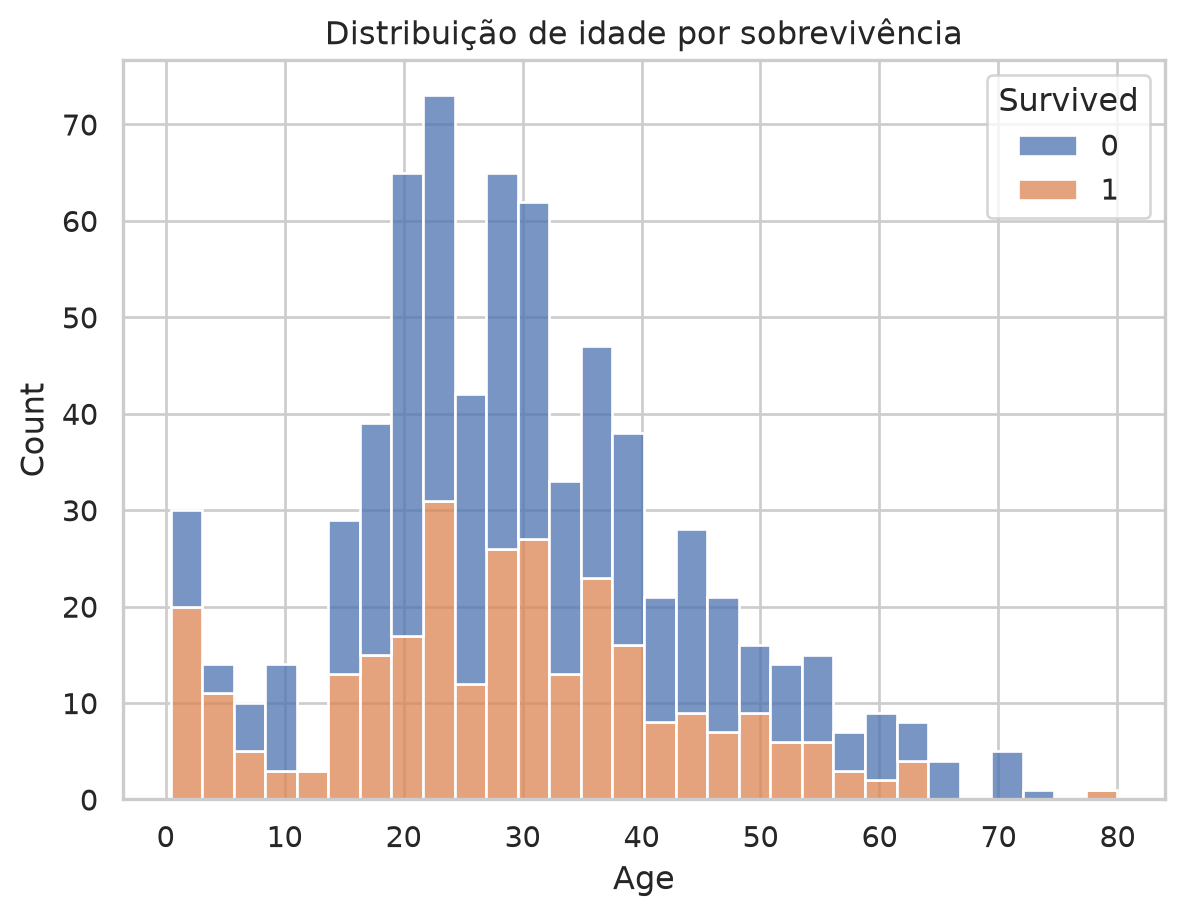

In [5]:
df_idade = df.dropna(subset=["Age"])

sns.histplot(
    data=df_idade, x="Age", hue="Survived", multiple="stack", bins=30
)
plt.title("Distribuição de idade por sobrevivência")
plt.show()

## Conclusões

- A taxa geral de sobrevivência foi de cerca de 38%.
- Sexo é o fator mais determinante: mulheres sobreviveram a uma taxa muito maior que homens.
- Classe do passageiro também importa bastante — 1ª classe teve prioridade e melhor acesso aos botes.
- Crianças pequenas tiveram uma sobrevivência proporcionalmente maior, reforçando o padrão "mulheres e crianças primeiro".

Próximos passos: usar essas variáveis (sexo, classe, idade, tarifa) para treinar um modelo de classificação e comparar com esta análise descritiva.